import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

Dataset Acquisition

In [2]:
file_path = "/content/Heart_Failure_Details.csv"

In [3]:
df = pd.read_csv(file_path)

In [4]:
file_path = "/content/Heart_Failure_Details.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


load dataset

In [5]:
print("First 5 rows of dataset:")

display(df.head())

First 5 rows of dataset:


,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death
0,1,75.0,0,582,0,20,1,265000.00,1.9,1,0,1
1,2,55.0,0,7861,0,38,0,263358.03,1.1,1,0,1
2,3,65.0,0,146,0,20,0,162000.00,1.3,1,1,1
3,4,50.0,1,111,0,20,0,210000.00,1.9,1,0,1
4,5,65.0,1,160,1,20,0,327000.00,2.7,0,0,1


summarize the dataset

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 299
Columns: 12


data types

In [7]:
print(df.dtypes)

S no.                         int64
age                         float64
anaemia                       int64
creatinine phosphokinase      int64
diabetes                      int64
ejection fraction             int64
high bp                       int64
platelets                   float64
serum creatinine            float64
sex                           int64
smoking                       int64
death                         int64
dtype: object


missing values

In [8]:
print(df.isnull().sum())

S no.                       0
age                         0
anaemia                     0
creatinine phosphokinase    0
diabetes                    0
ejection fraction           0
high bp                     0
platelets                   0
serum creatinine            0
sex                         0
smoking                     0
death                       0
dtype: int64


visualize missing value

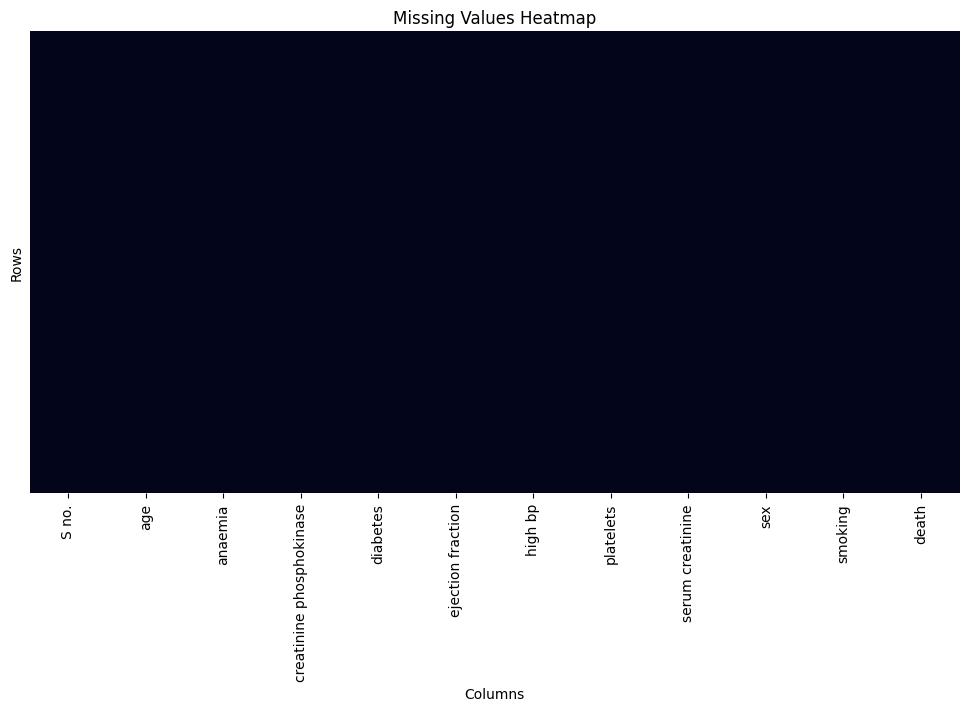

In [9]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

plot distributions

In [10]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['S no.', 'age', 'anaemia', 'creatinine phosphokinase', 'diabetes',
       'ejection fraction', 'high bp', 'platelets', 'serum creatinine', 'sex',
       'smoking', 'death'],
      dtype='object')


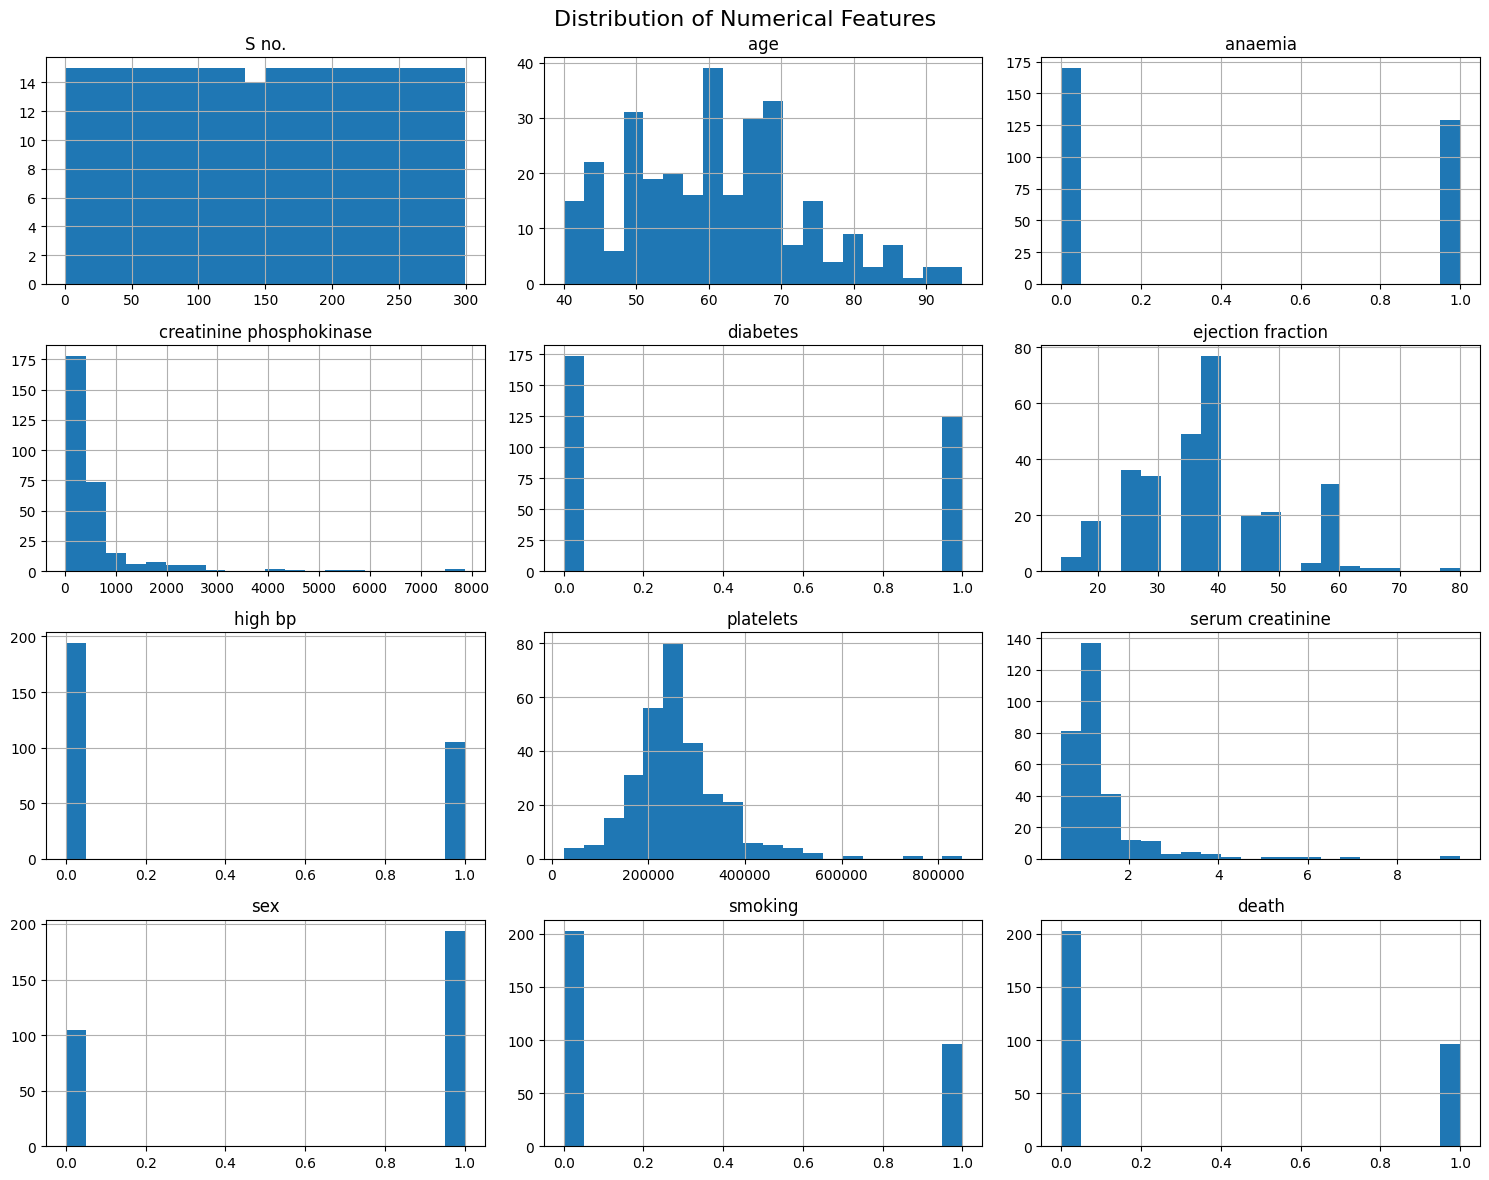

In [11]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

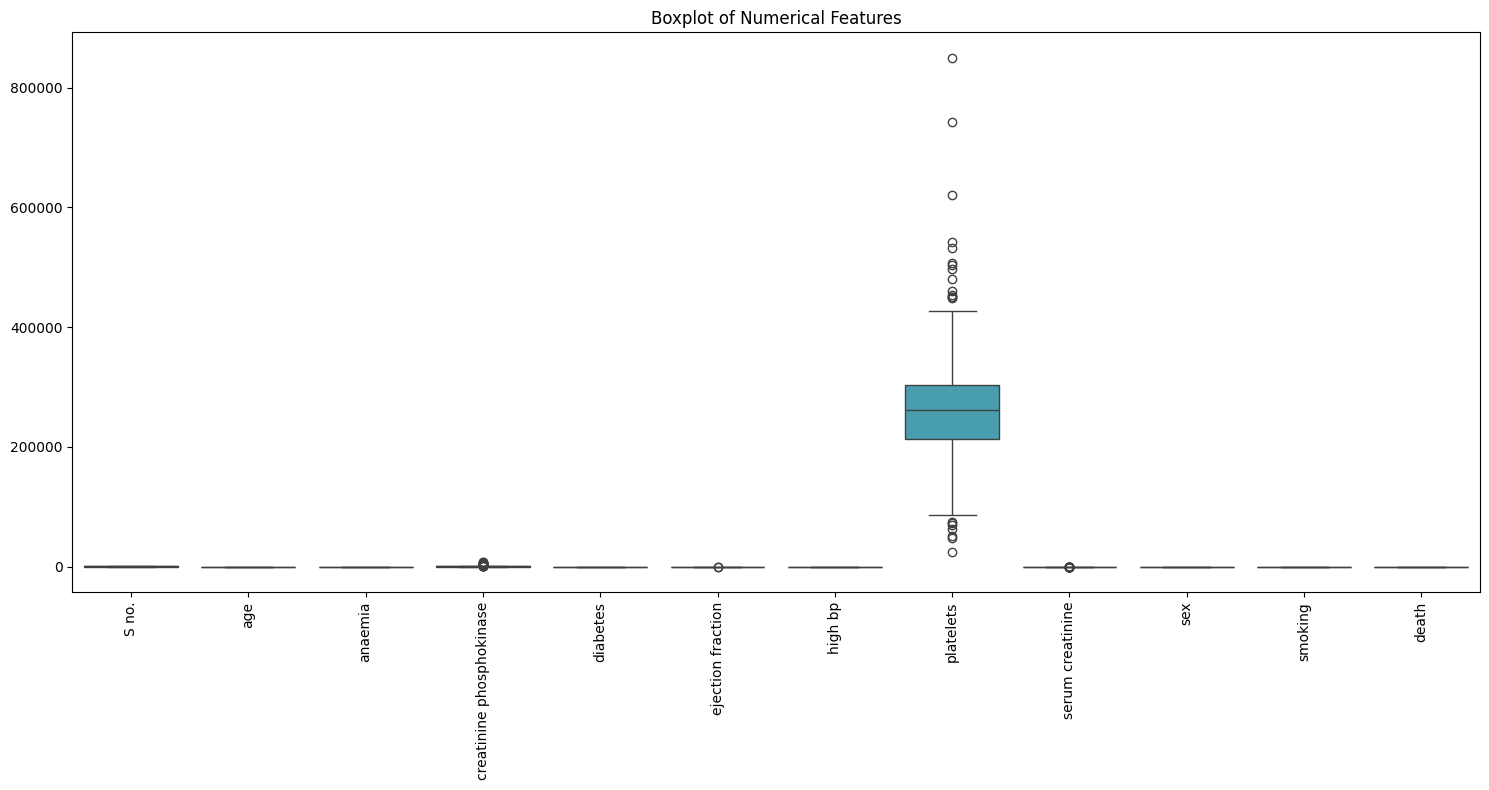

In [12]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numeric_columns]
)

plt.xticks(rotation=90)

plt.title("Boxplot of Numerical Features")

plt.tight_layout()

plt.show()

original dataset

In [13]:
df_before_cleaning = df.copy()

correct inconsistencies

In [14]:
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Minimum age: 40.0
Maximum age: 95.0


In [15]:
negative_age = df[df["age"] < 0]

print("Negative age records:")
display(negative_age)

Negative age records:


,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death


In [16]:
df.loc[df["age"] < 0, "age"] = np.nan

In [17]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    print("\nColumn:", col)
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


Column: S no.
Minimum: 1
Maximum: 299

Column: age
Minimum: 40.0
Maximum: 95.0

Column: anaemia
Minimum: 0
Maximum: 1

Column: creatinine phosphokinase
Minimum: 23
Maximum: 7861

Column: diabetes
Minimum: 0
Maximum: 1

Column: ejection fraction
Minimum: 14
Maximum: 80

Column: high bp
Minimum: 0
Maximum: 1

Column: platelets
Minimum: 25100.0
Maximum: 850000.0

Column: serum creatinine
Minimum: 0.5
Maximum: 9.4

Column: sex
Minimum: 0
Maximum: 1

Column: smoking
Minimum: 0
Maximum: 1

Column: death
Minimum: 0
Maximum: 1


impute missing value

In [18]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

In [19]:
for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [20]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

In [21]:
for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        mode_value = df[col].mode()

        if len(mode_value) > 0:

            df[col] = df[col].fillna(
                mode_value[0]
            )

        else:

            df[col] = df[col].fillna(
                "Unknown"
            )

In [22]:
print(df.isnull().sum())

S no.                       0
age                         0
anaemia                     0
creatinine phosphokinase    0
diabetes                    0
ejection fraction           0
high bp                     0
platelets                   0
serum creatinine            0
sex                         0
smoking                     0
death                       0
dtype: int64


remove outliers

In [23]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

df_clean = df.copy()

for col in numeric_columns:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

In [24]:
print("Rows before outlier removal:", len(df))
print("Rows after outlier removal:", len(df_clean))

Rows before outlier removal: 299
Rows after outlier removal: 227


In [25]:
df = df_clean.reset_index(drop=True)

featuring engineering

In [26]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

In [27]:
print(df["age_group"].value_counts())

age_group
>60      126
40-60    101
<40        0
Name: count, dtype: int64


Create risk_score

In [28]:
ef_norm = (
    (df["ejection fraction"] -
     df["ejection fraction"].min())
    /
    (df["ejection fraction"].max() -
     df["ejection fraction"].min())
)

In [29]:
creat_norm = (
    (df["serum creatinine"] -
     df["serum creatinine"].min())
    /
    (df["serum creatinine"].max() -
     df["serum creatinine"].min())
)

In [30]:
df["risk_score"] = (
    (1 - ef_norm) * creat_norm
)

In [31]:
display(
    df[
        [
            "ejection fraction",
            "serum creatinine",
            "risk_score"
        ]
    ].head()
)

,ejection fraction,serum creatinine,risk_score
0,20,1.9,0.764706
1,20,1.3,0.411765
2,20,1.9,0.764706
3,40,2.1,0.490196
4,15,1.2,0.392157


Encode Categorical Variables

In [32]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['age_group']


In [33]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

Normalize Features

In [34]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

In [35]:
target_columns = [
    "DEATH_EVENT",
    "death_event",
    "target",
    "Target"
]

In [36]:
features_to_scale = [
    col for col in numeric_columns
    if col not in target_columns
]

In [37]:
scaler = MinMaxScaler()

In [38]:
df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

In [39]:
display(df.head())

,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death,risk_score,age_group_40-60,age_group_>60
0,0.000000,0.636364,0.0,0.467401,0.0,0.117647,1.0,0.523529,0.866667,1.0,0.0,1.0,0.812500,False,True
1,0.006711,0.454545,0.0,0.098222,0.0,0.117647,0.0,0.220588,0.466667,1.0,1.0,1.0,0.437500,False,True
2,0.010067,0.181818,1.0,0.068586,0.0,0.117647,0.0,0.361765,0.866667,1.0,0.0,1.0,0.812500,True,False
3,0.016779,0.909091,1.0,0.014395,0.0,0.509804,1.0,0.344118,1.000000,1.0,1.0,1.0,0.520833,False,True
4,0.020134,0.636364,1.0,0.182896,0.0,0.019608,0.0,0.117647,0.400000,1.0,0.0,1.0,0.416667,False,True


Calculate Summary Statistics — Before Cleaning

In [40]:
df_before_cleaning

,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death
0,1,75.0,0,582,0,20,1,265000.00,1.9,1,0,1
1,2,55.0,0,7861,0,38,0,263358.03,1.1,1,0,1
2,3,65.0,0,146,0,20,0,162000.00,1.3,1,1,1
3,4,50.0,1,111,0,20,0,210000.00,1.9,1,0,1
4,5,65.0,1,160,1,20,0,327000.00,2.7,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,295,62.0,0,61,1,38,1,155000.00,1.1,1,1,0
295,296,55.0,0,1820,0,38,0,270000.00,1.2,0,0,0
296,297,45.0,0,2060,1,60,0,742000.00,0.8,0,0,0
297,298,45.0,0,2413,0,38,0,140000.00,1.4,1,1,0


In [41]:
before_stats = df_before_cleaning.select_dtypes(
    include=np.number
).agg(
    ["mean", "median", "std"]
).T

display(before_stats)

,mean,median,std
S no.,150.000000,150.0,86.458082
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection fraction,38.083612,38.0,11.834841
high bp,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum creatinine,1.393880,1.1,1.034510
sex,0.648829,1.0,0.478136


Calculate Summary Statistics — After Cleaning

In [42]:
after_stats = df.select_dtypes(
    include=np.number
).agg(
    ["mean", "median", "std"]
).T

display(after_stats)

,mean,median,std
S no.,0.507199,0.516779,0.286070
age,0.376078,0.363636,0.217041
anaemia,0.466960,0.000000,0.500010
creatinine phosphokinase,0.263444,0.154107,0.240763
diabetes,0.427313,0.000000,0.495782
ejection fraction,0.473439,0.470588,0.230842
high bp,0.378855,0.000000,0.486174
platelets,0.494768,0.517647,0.198976
serum creatinine,0.359471,0.333333,0.225795
sex,0.638767,1.000000,0.481420


Validate Cleaning

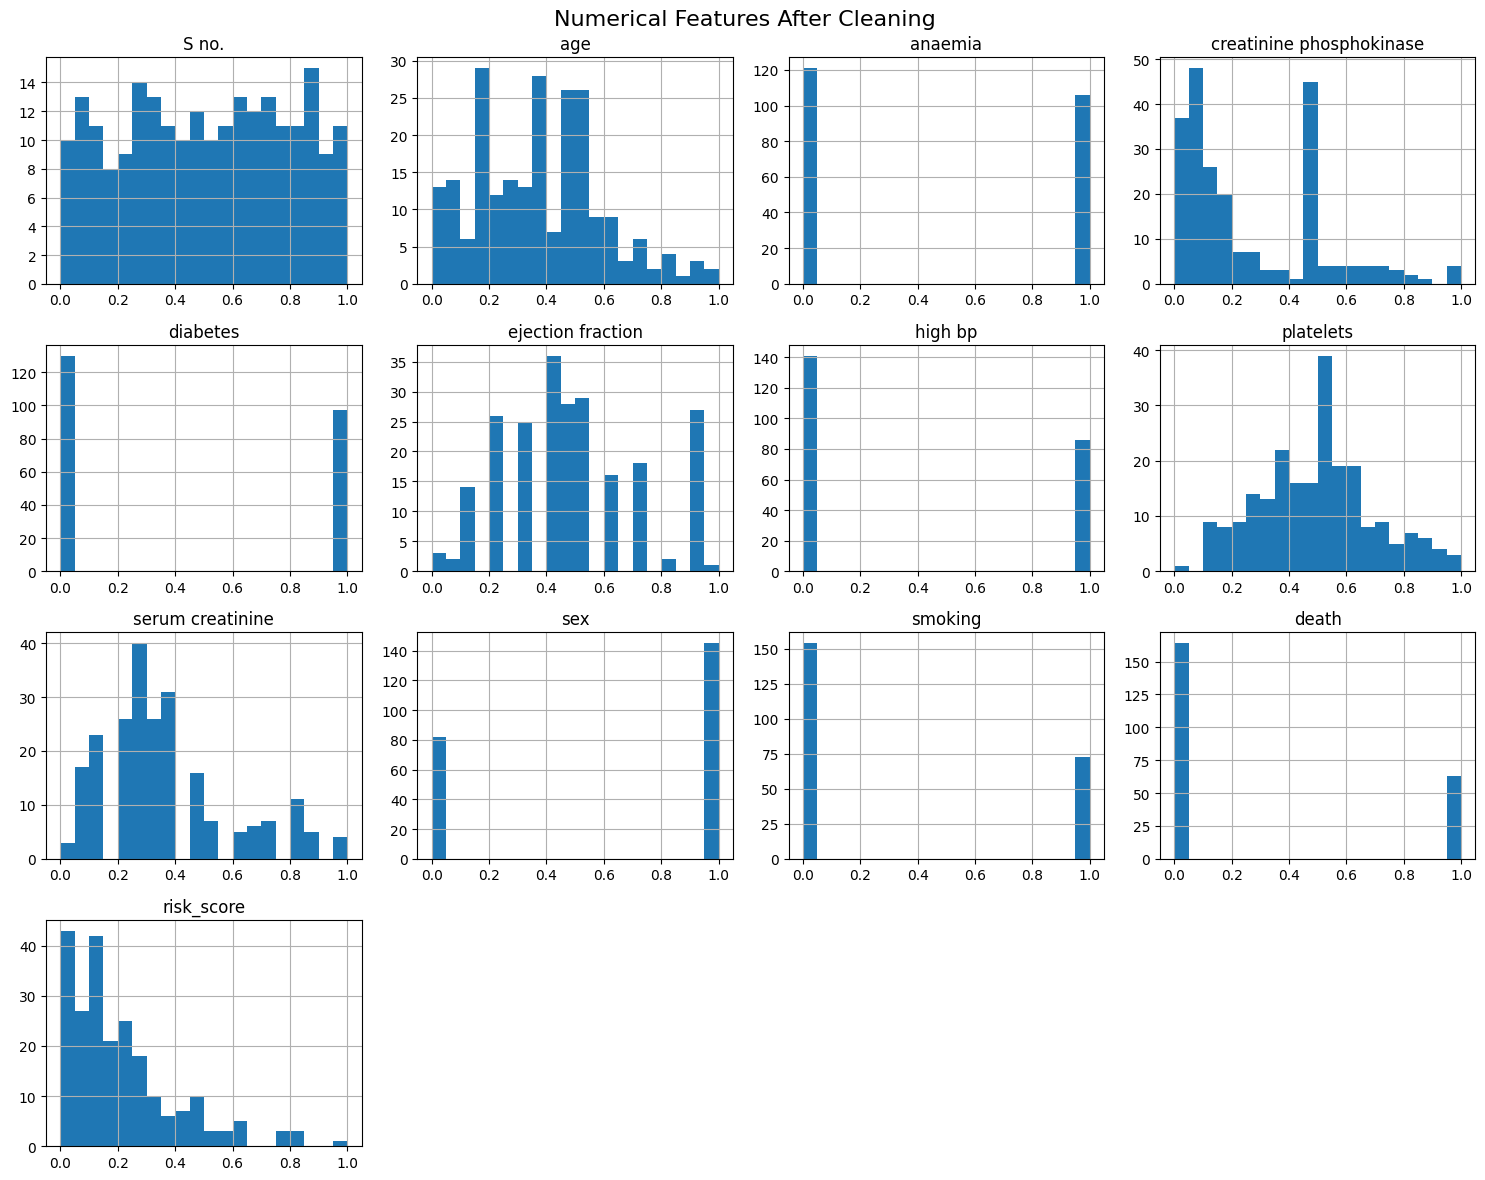

In [43]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Numerical Features After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

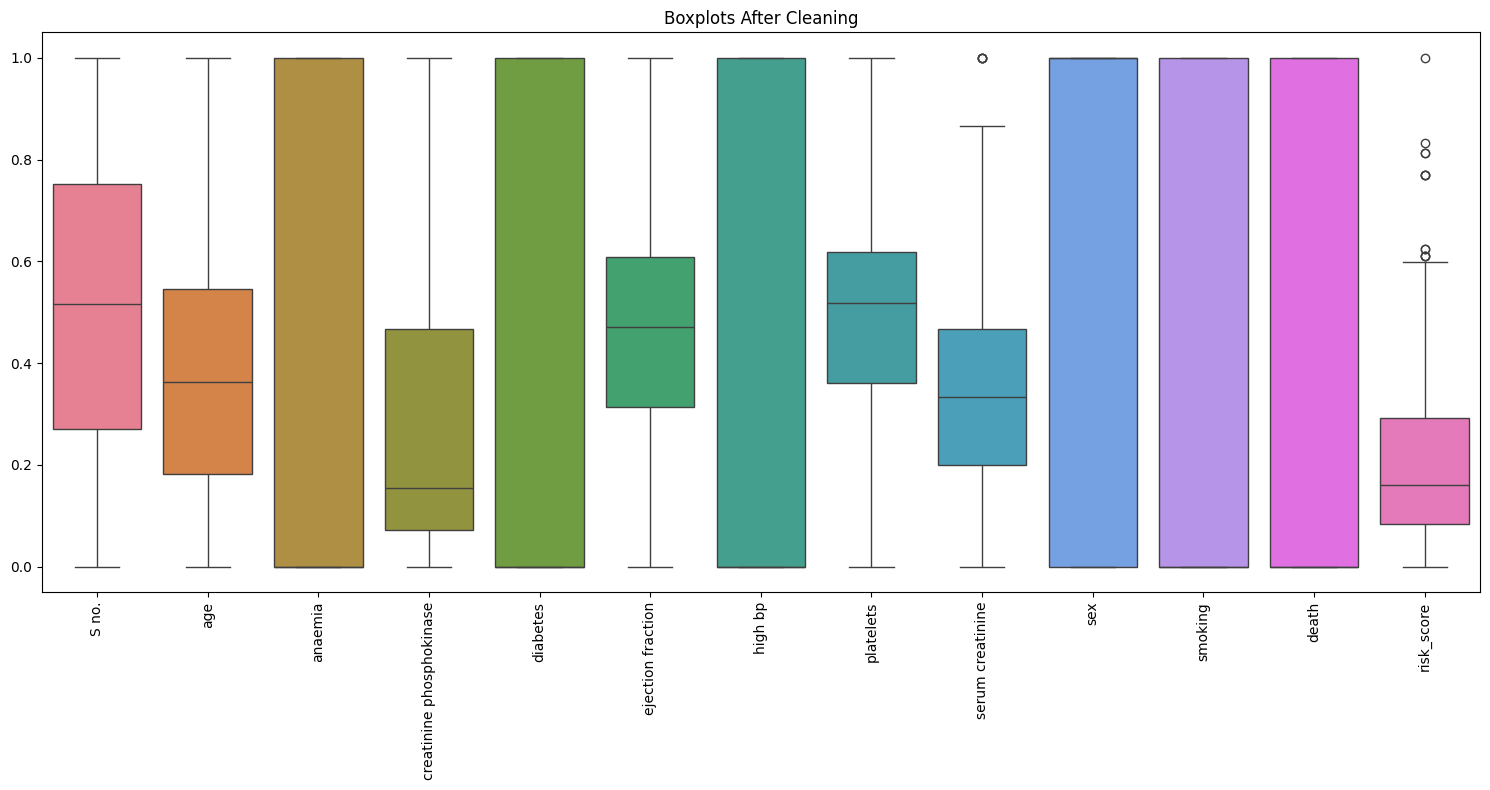

In [44]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numeric_columns]
)

plt.xticks(rotation=90)

plt.title(
    "Boxplots After Cleaning"
)

plt.tight_layout()

plt.show()

Final Missing Value Check

In [45]:

print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
S no.                       0
age                         0
anaemia                     0
creatinine phosphokinase    0
diabetes                    0
ejection fraction           0
high bp                     0
platelets                   0
serum creatinine            0
sex                         0
smoking                     0
death                       0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64


In [46]:
total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)


Total missing values: 0


In [47]:
if total_missing == 0:
    print("SUCCESS: No missing values remain.")
else:
    print("Missing values still remain.")

SUCCESS: No missing values remain.


Final Dataset Information

In [48]:
print("Final dataset shape:")
print(df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFinal data types:")
print(df.dtypes)

print("\nFinal dataset:")
display(df.head())

Final dataset shape:
(227, 15)

Final columns:
['S no.', 'age', 'anaemia', 'creatinine phosphokinase', 'diabetes', 'ejection fraction', 'high bp', 'platelets', 'serum creatinine', 'sex', 'smoking', 'death', 'risk_score', 'age_group_40-60', 'age_group_>60']

Final data types:
S no.                       float64
age                         float64
anaemia                     float64
creatinine phosphokinase    float64
diabetes                    float64
ejection fraction           float64
high bp                     float64
platelets                   float64
serum creatinine            float64
sex                         float64
smoking                     float64
death                       float64
risk_score                  float64
age_group_40-60                bool
age_group_>60                  bool
dtype: object

Final dataset:


,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death,risk_score,age_group_40-60,age_group_>60
0,0.000000,0.636364,0.0,0.467401,0.0,0.117647,1.0,0.523529,0.866667,1.0,0.0,1.0,0.812500,False,True
1,0.006711,0.454545,0.0,0.098222,0.0,0.117647,0.0,0.220588,0.466667,1.0,1.0,1.0,0.437500,False,True
2,0.010067,0.181818,1.0,0.068586,0.0,0.117647,0.0,0.361765,0.866667,1.0,0.0,1.0,0.812500,True,False
3,0.016779,0.909091,1.0,0.014395,0.0,0.509804,1.0,0.344118,1.000000,1.0,1.0,1.0,0.520833,False,True
4,0.020134,0.636364,1.0,0.182896,0.0,0.019608,0.0,0.117647,0.400000,1.0,0.0,1.0,0.416667,False,True


In [49]:
output_path = "/content/Heart_Failure_Cleaned.csv"

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
/content/Heart_Failure_Cleaned.csv
